#### Conforming to Statistical Assumptions

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
data = pd.read_csv("./datasets/Combined_DS_v10.csv")
numeric_cols = data.dtypes[data.dtypes != 'object'].index
data_numeric = data[numeric_cols]

##### What Does Your Data Look Like ? (1)

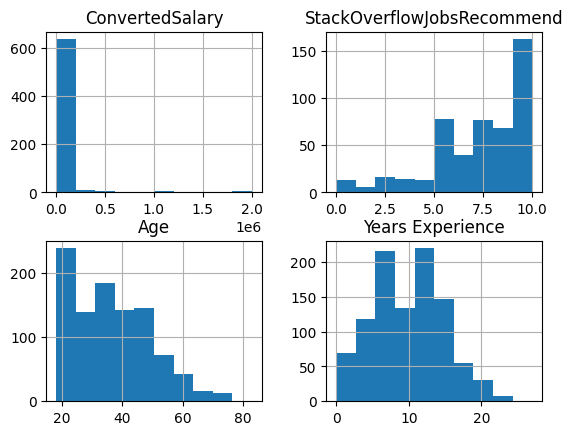

In [ ]:
# create histogram
data_numeric.hist()
plt.show()

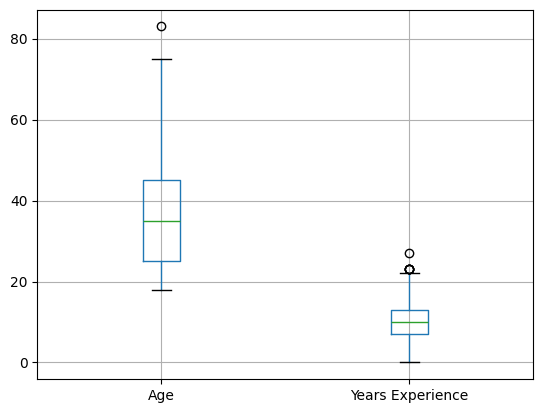

In [14]:
# create boxplot
data_numeric[["Age", "Years Experience"]].boxplot()
plt.show()

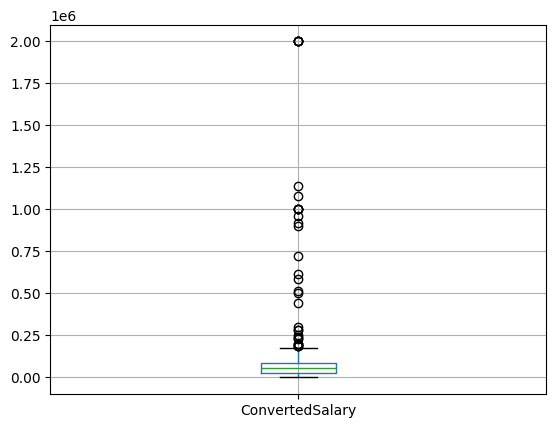

In [16]:
# create boxplot of the converted salary
data_numeric[["ConvertedSalary"]].boxplot()
plt.show()

##### What Does Your Data Look Like (2)

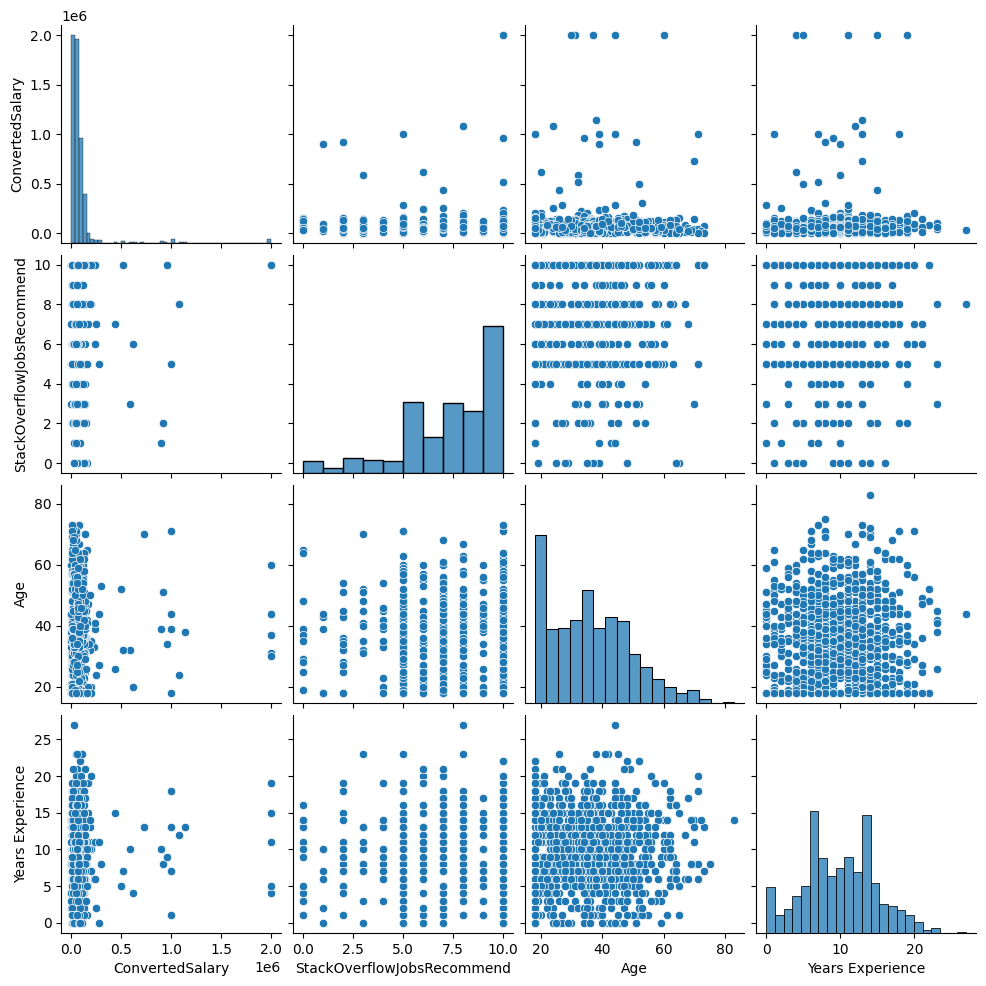

In [18]:
# create a pair plot
sns.pairplot(data_numeric)
plt.show()

##### Normalization

In [25]:
from sklearn.preprocessing import MinMaxScaler

MM_scaler = MinMaxScaler()
MM_scaler.fit(data_numeric[["Age"]])
data_numeric.loc[:, "Age_MM"] = MM_scaler.transform(data_numeric[["Age"]])

display(data_numeric[["Age", "Age_MM"]].head())

,Age,Age_MM
0,21,0.046154
1,38,0.307692
2,45,0.415385
3,46,0.430769
4,39,0.323077


##### Standardization

In [ ]:
from sklearn.preprocessing import StandardScaler

SS_scaler = StandardScaler()
SS_scaler.fit(data_numeric[["Age"]])
data_numeric.loc[:, "Age_SS"] = SS_scaler.transform(data_numeric[["Age"]])
display(data_numeric[["Age", "Age_SS"]].head())

,Age,Age_SS
0,21,-1.132431
1,38,0.150734
2,45,0.679096
3,46,0.754576
4,39,0.226214


##### Log Transformation

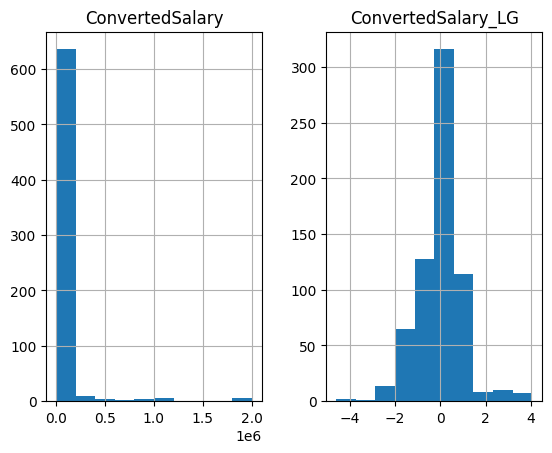

In [29]:
from sklearn.preprocessing import PowerTransformer

pow_trans = PowerTransformer()
pow_trans.fit(data_numeric[["ConvertedSalary"]])
data_numeric.loc[:, "ConvertedSalary_LG"] = pow_trans.transform(data_numeric[["ConvertedSalary"]])

data_numeric[["ConvertedSalary", "ConvertedSalary_LG"]].hist()
plt.show()

##### Outlier Removal

Percentage Based Outlier Removal

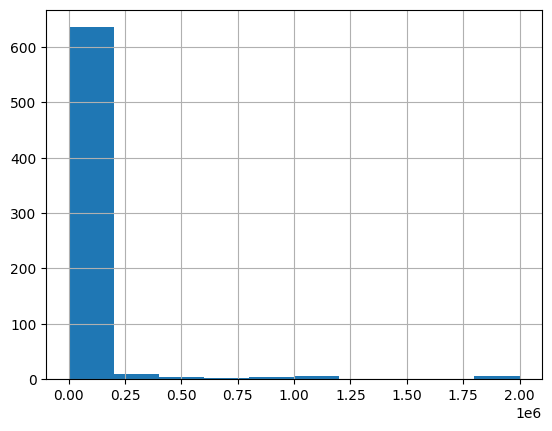

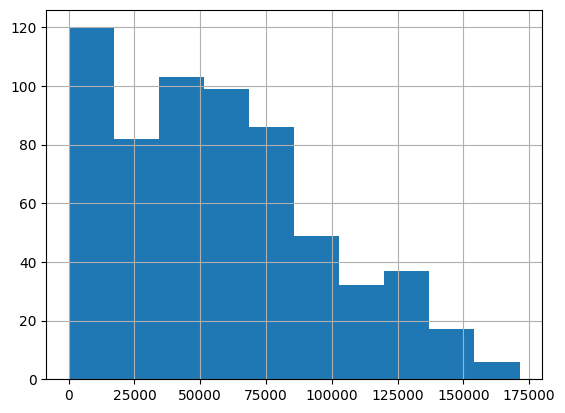

In [32]:
quantile = data_numeric["ConvertedSalary"].quantile(0.95)
trimmed_df = data_numeric[data_numeric["ConvertedSalary"] < quantile]

# plot "ComputedSalary" before removing outliers
data_numeric["ConvertedSalary"].hist()
plt.show()

# plot "ComputedSalary" after removing outliers
trimmed_df["ConvertedSalary"].hist()
plt.show()

Statistical Outlier Removal

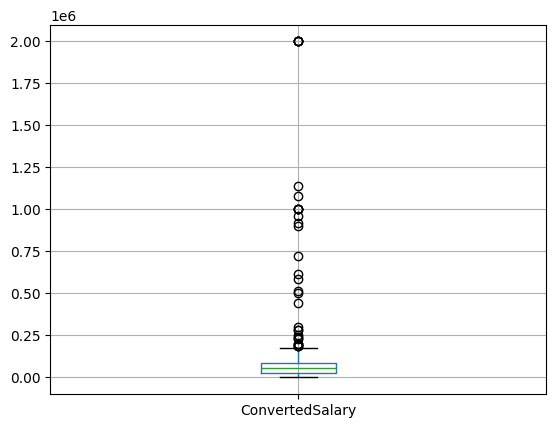

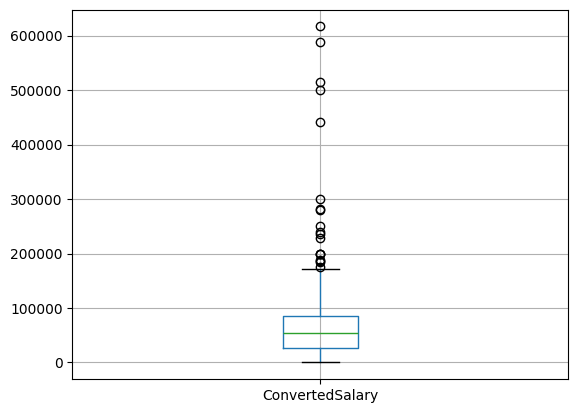

In [38]:
# all the data points before and after 3 standard daviation from the mean are outliers

mean = data_numeric["ConvertedSalary"].mean()
std = data_numeric["ConvertedSalary"].std()

cutoff = std * 3
lower, upper = mean - cutoff, mean + cutoff

trimmed_df = data_numeric[(data_numeric["ConvertedSalary"] > lower) & \
                           (data_numeric["ConvertedSalary"] < upper)]

data_numeric[["ConvertedSalary"]].boxplot()
plt.show()
trimmed_df[["ConvertedSalary"]].boxplot()
plt.show()

##### Training and Transforming New Data

In [ ]:
n = data_numeric.shape[0]
train_size = 800
data_train_numeric = data_numeric.iloc[:train_size, :]
data_test_numeric = data_numeric.iloc[train_size+1: , :]

In [43]:
data_train_numeric.shape[0], data_test_numeric.shape[0]

(800, 198)

Train and Testing Transformations (I)

In [45]:
# fit the data on the training set and transform it on the test set

from sklearn.preprocessing import StandardScaler

SS_scaler = StandardScaler()
SS_scaler.fit(data_train_numeric[["Age"]])

data_test_numeric.loc[:, "Age_SS"] = SS_scaler.transform(data_test_numeric[["Age"]])

Train and Testing Transformations (2)

In [46]:
train_mean = data_train_numeric["ConvertedSalary"].mean()
train_std = data_train_numeric["ConvertedSalary"].std()

cutoff = train_std * 3
train_lower, train_upper = train_mean - cutoff, train_mean + cutoff

trimmed_df = data_test_numeric[(data_test_numeric["ConvertedSalary"] > train_lower)\
                                & data_test_numeric["ConvertedSalary"] < train_upper]